# Plaquette Wide Band

Four-site plaquette cluster with wide-band (continuous) bath.

In [1]:
import sys
sys.path.append('../common')
from model import *
from analysis import load_all_results, compute_sigma, deviation_table, \
    plot_iw_comparison, plot_w_comparison, plot_static_obs_table, plot_chi_contour

In [2]:
data = load_all_results()
block_lst = list(data[next(iter(data))]['G'].indices) if data else []

## 1. Single-Particle Green Function $G(i\omega_n)$


  G max-norm deviations:
                alps_cthyb       cthyb       ctint
    alps_cthyb                1.48e+00    1.30e+00
         cthyb                            3.87e-01
         ctint                                    


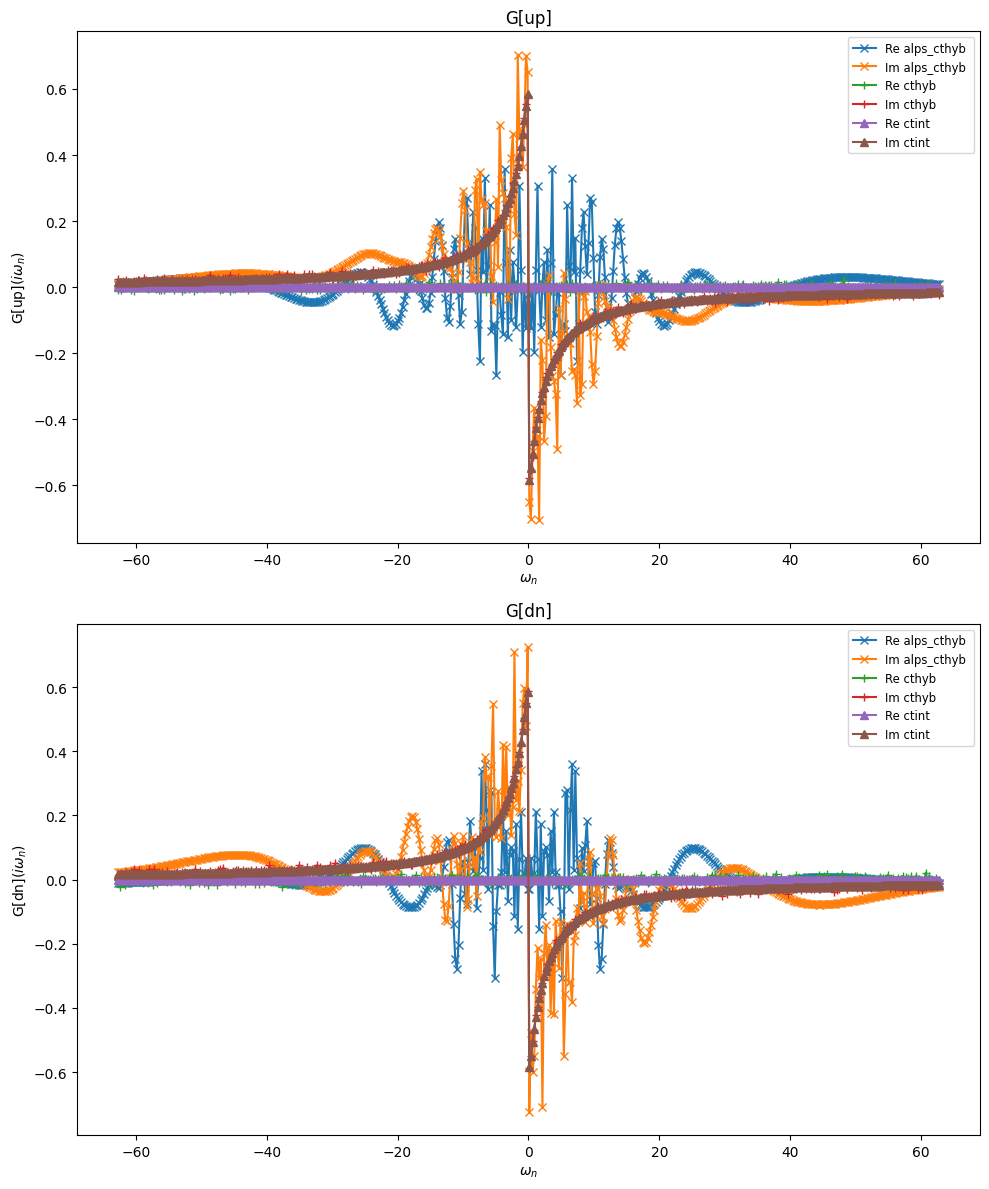

In [3]:
G_dict = {s: d['G'] for s, d in data.items() if 'G' in d}
if G_dict:
    plot_iw_comparison(G_dict, 'G', block_lst)
    deviation_table(G_dict, block_lst, label='G')

## 2. Self-Energy $\Sigma(i\omega_n)$


  Sigma max-norm deviations:
                alps_cthyb       cthyb       ctint
    alps_cthyb                7.74e+02    6.25e+02
         cthyb                            7.39e+02
         ctint                                    


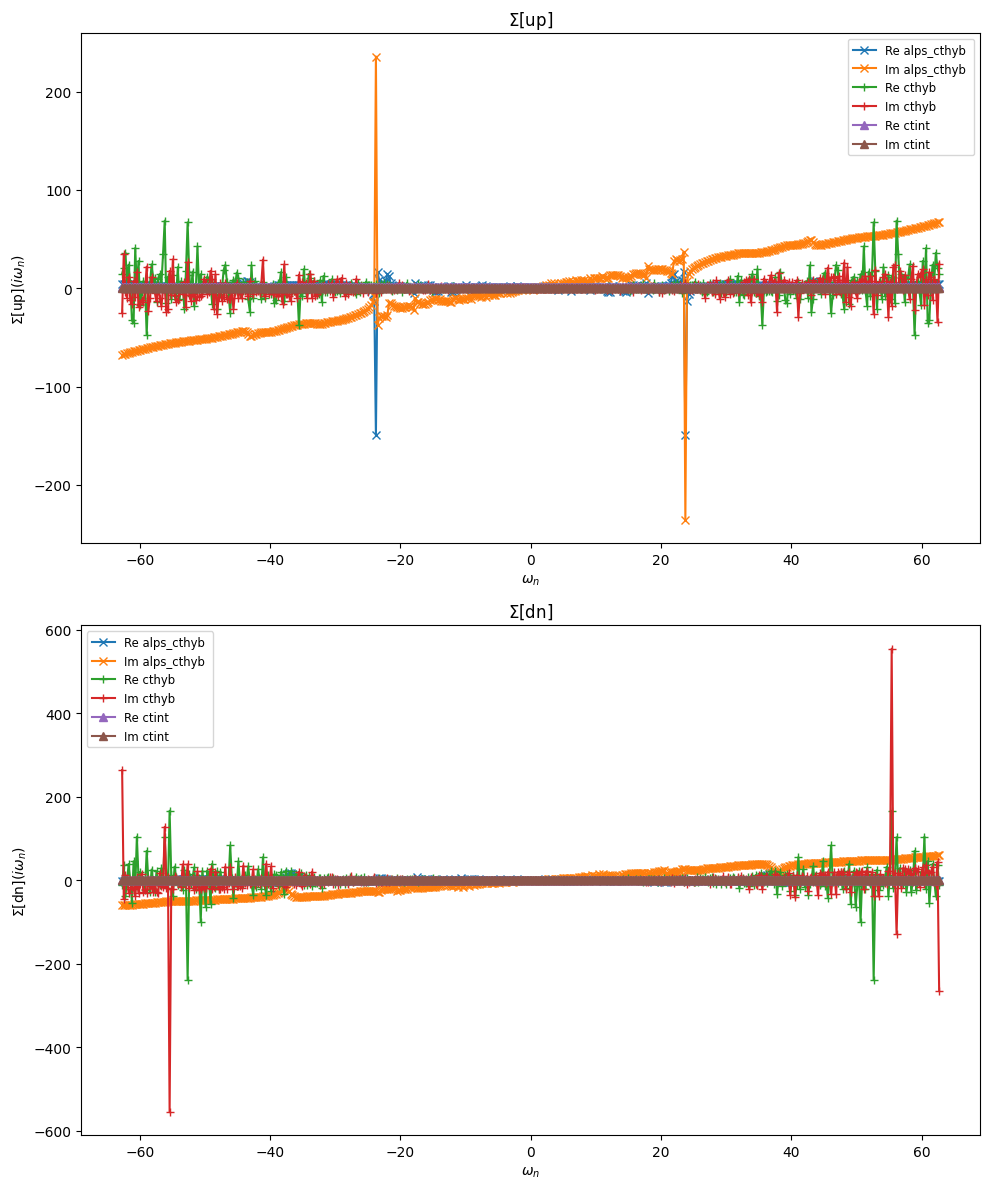

In [4]:
Sigma_dict = compute_sigma(data, G0_iw)
if Sigma_dict:
    plot_iw_comparison(Sigma_dict, r'$\Sigma$', block_lst)
    deviation_table(Sigma_dict, block_lst, label='Sigma')

## 3. Static Observables

In [5]:
plot_static_obs_table(data, 'density')
plot_static_obs_table(data, 'nn_ab')


  density:
    cthyb                 dn_0: 0.503744, dn_1: 0.496214, dn_2: 0.498339, dn_3: 0.497837, up_0: 0.497255, up_1: 0.503447, up_2: 0.499894, up_3: 0.501602
    ctint                 dn_0: 0.499886, dn_1: 0.500153, dn_2: 0.500278, dn_3: 0.499980, up_0: 0.500114, up_1: 0.499847, up_2: 0.499722, up_3: 0.500020

  nn_ab:
    cthyb                 dn_0,dn_0: 0.503744, dn_0,dn_1: 0.197276, dn_0,dn_2: 0.198396, dn_0,dn_3: 0.253621, dn_0,up_0: 0.194088, dn_0,up_1: 0.267978, dn_0,up_2: 0.267741, dn_0,up_3: 0.245406, dn_1,dn_0: 0.197276, dn_1,dn_1: 0.496214, dn_1,dn_2: 0.250947, dn_1,dn_3: 0.195919, dn_1,up_0: 0.262298, dn_1,up_1: 0.194403, dn_1,up_2: 0.240689, dn_1,up_3: 0.263902, dn_2,dn_0: 0.198396, dn_2,dn_1: 0.250947, dn_2,dn_2: 0.498339, dn_2,dn_3: 0.194344, dn_2,up_0: 0.263899, dn_2,up_1: 0.241792, dn_2,up_2: 0.193150, dn_2,up_3: 0.266615, dn_3,dn_0: 0.253621, dn_3,dn_1: 0.195919, dn_3,dn_2: 0.194344, dn_3,dn_3: 0.497837, dn_3,up_0: 0.239996, dn_3,up_1: 0.265231, dn_3,up_2: 0.263

## 4. Real-Frequency Spectral Function $A(\omega)$

In [6]:
G_w_dict = {s: d['G_w'] for s, d in data.items() if 'G_w' in d}
if G_w_dict:
    plot_w_comparison(G_w_dict, 'G_w', block_lst, spectral=True)
else:
    print("No solver has real-frequency data.")

No solver has real-frequency data.


## 5. Three-Point Correlator $\chi_3$

In [7]:
for ch in ['d', 'm', 's', 't']:
    key = f'chi3_{ch}'
    chi3 = {s: d[key] for s, d in data.items() if key in d}
    if chi3:
        plot_chi_contour(chi3, ch)

## 6. Two-Particle Green Function $\chi_4$ / $G_{2c}$

In [8]:
for ch in ['d', 'm', 's', 't']:
    key = f'chi4_{ch}'
    chi4 = {s: d[key] for s, d in data.items() if key in d}
    if chi4:
        plot_chi_contour(chi4, ch)